import libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving corporate_ai_adoption_dataset.csv to corporate_ai_adoption_dataset.csv


load dataset

In [ ]:
df = pd.read_csv("corporate_ai_adoption_dataset.csv")

Basic inspection

In [ ]:
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

In [ ]:
df.shape

(200000, 13)

In [ ]:
df.columns

Index(['company_id', 'industry', 'country', 'year', 'ai_adoption_level',
       'ai_investment_usd', 'automation_rate', 'cost_savings',
       'revenue_impact', 'productivity_gain', 'employee_ai_training_hours',
       'ai_maturity_score', 'deployment_count'],
      dtype='object')

missing values

In [ ]:
df.isnull().sum()

,0
company_id,0
industry,0
country,0
year,0
ai_adoption_level,0
ai_investment_usd,0
automation_rate,0
cost_savings,0
revenue_impact,0
productivity_gain,0


Duplicate records

In [ ]:
df.duplicated().sum()

np.int64(0)

statistical summary

In [ ]:
df.describe()

,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
count,200000.000000,200000.000000,2.000000e+05,200000.000000,2.000000e+05,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000
mean,2024.991490,0.527774,4.870558e+06,0.436723,2.128918e+06,2.591989e+06,0.395297,76.755334,6.271801,26.337350
std,6.051632,0.256470,3.679704e+06,0.217031,2.415689e+06,3.972751e+06,0.195623,40.046317,1.930643,11.853256
min,2015.000000,0.010000,4.788800e+04,0.000000,4.649000e+03,-1.437676e+07,-0.050000,1.000000,1.000000,3.000000
25%,2020.000000,0.334400,2.221252e+06,0.273500,5.993548e+05,5.339805e+05,0.249300,46.500000,4.730000,16.000000
50%,2025.000000,0.528600,3.991640e+06,0.428150,1.354826e+06,1.408779e+06,0.392600,75.400000,6.280000,25.000000
75%,2030.000000,0.725000,6.517931e+06,0.592000,2.745080e+06,3.132148e+06,0.539300,105.900000,7.830000,36.000000
max,2035.000000,1.000000,5.417034e+07,0.950000,4.433124e+07,1.294787e+08,0.940300,197.900000,10.000000,58.000000


phase:2 Descriptive statistical analysis
Average productivity gain

In [ ]:
df["productivity_gain"].mean()

np.float64(0.39529702899999997)

Median productivity gain

In [ ]:
df["productivity_gain"].median()

0.3926

Standard deviation

In [ ]:
df["productivity_gain"].std()

0.19562343136855134

Quartiles

In [ ]:
df["productivity_gain"].quantile([0.25,0.50,0.75])

Percentiles

In [ ]:
df["productivity_gain"].quantile([0.1,0.9])

,productivity_gain
0.1,0.1338
0.9,0.6604


Average ai usage by industry

In [ ]:
industry_adoption = (
    df.groupby("industry")
    ["ai_adoption_level"]
    .mean()
    .sort_values(ascending=False)
)

industry_adoption

,ai_adoption_level
industry,
Energy,0.531567
Agriculture,0.529958
Financial Services,0.529080
Healthcare,0.528715
Retail,0.528244
Manufacturing,0.527988
Logistics,0.527442
Telecom,0.526586
Technology,0.525667


Company distribution by industry

In [ ]:
df["industry"].value_counts()

,count
industry,
Technology,35994
Manufacturing,29884
Financial Services,27927
Healthcare,24026
Retail,20048
Logistics,16021
Telecom,14128
Energy,14080
Agriculture,9934


phase 3: Trend investigation
trend 1: industry vs ai adoption

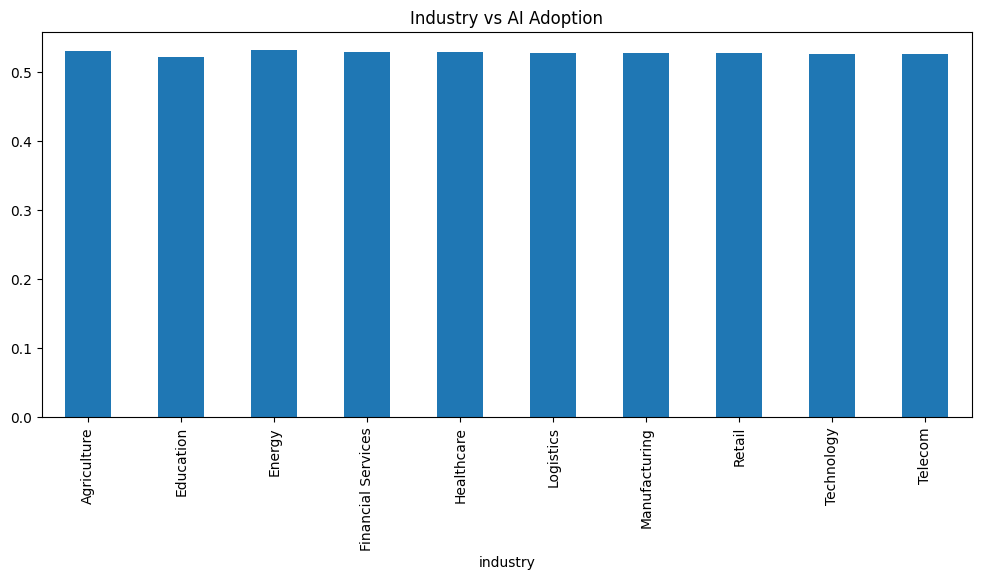

In [ ]:
industry_adoption = df.groupby("industry")[
    "ai_adoption_level"
].mean()

industry_adoption.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Industry vs AI Adoption")
plt.show()

trend 2: Year vs adoption growth

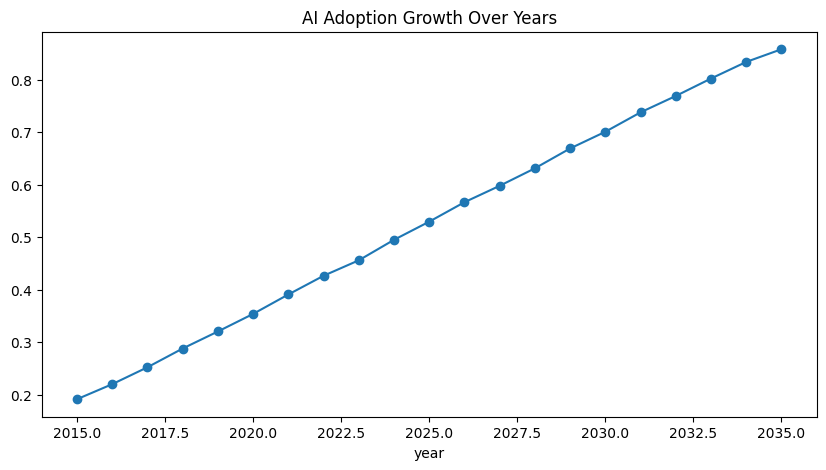

In [ ]:
year_growth = df.groupby("year")[
    "ai_adoption_level"
].mean()

year_growth.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("AI Adoption Growth Over Years")
plt.show()

trend 3: Ai investment vs productivity

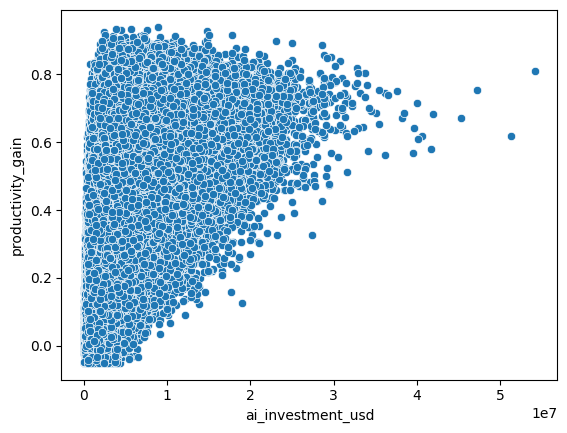

In [ ]:
sns.scatterplot(
    data=df,
    x="ai_investment_usd",
    y="productivity_gain"
)

plt.show()

trend 4: Employee training vs ai adoption

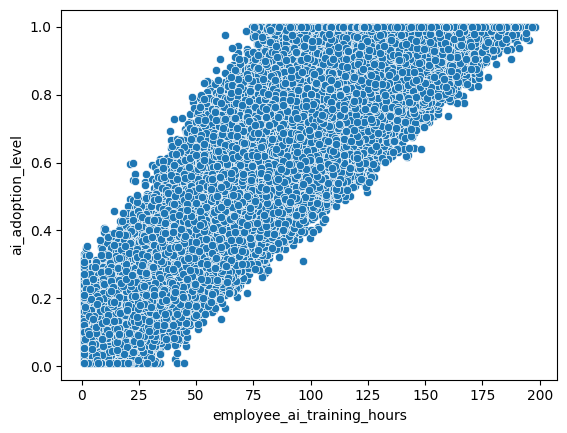

In [ ]:
sns.scatterplot(
    data=df,
    x="employee_ai_training_hours",
    y="ai_adoption_level"
)

plt.show()

trend 5: Ai maturity vs deployment count

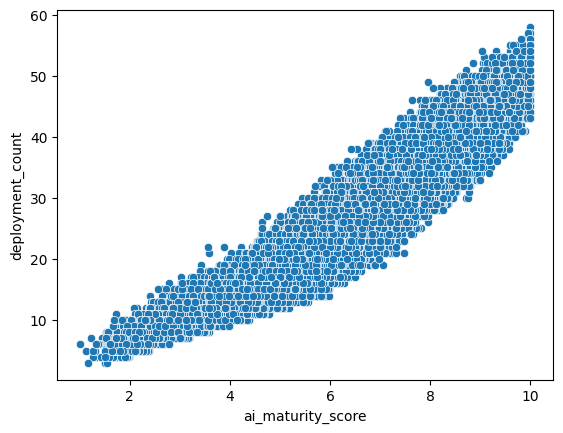

In [ ]:
sns.scatterplot(
    data=df,
    x="ai_maturity_score",
    y="deployment_count"
)

plt.show()

Phase 4: Correlation analysis

In [ ]:
corr = df.corr(numeric_only=True)

Heatmap

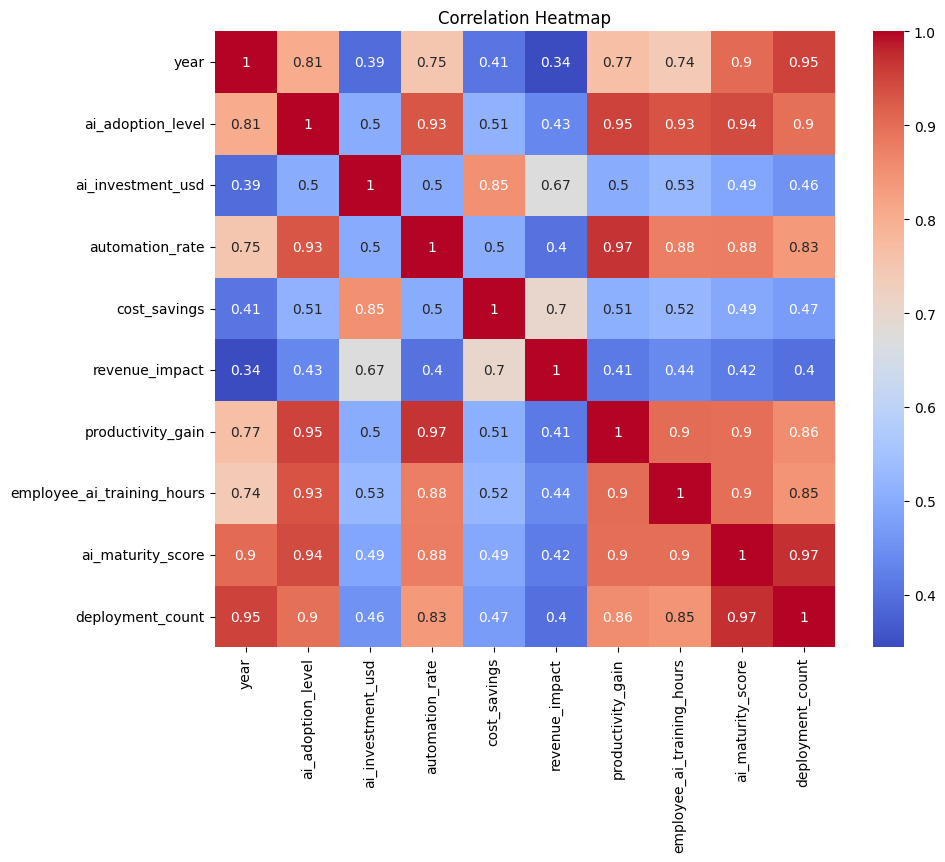

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

phase 5: hypothesis testing

In [ ]:
high = df[df["ai_maturity_score"] > 7]["ai_adoption_level"]

low = df[df["ai_maturity_score"] <= 7]["ai_adoption_level"]

T-test

In [ ]:
from scipy.stats import ttest_ind

t_stat,p_value = ttest_ind(
    high,
    low
)

print(p_value)

0.0


Interpretation

In [ ]:
if p_value<0.05:
  print("reject H0")
else:
  print("fail to reject H0")


reject H0


phase 6: Organization segmentation
ai leaders

In [ ]:
leaders = df[
    (df["ai_adoption_level"] > 80) &
    (df["ai_maturity_score"] > 8)
]

Early adaptors

In [ ]:
early = df[
    (df["year"] <= 2020)
]

high ROI companies

In [ ]:
roi = df[
    (df["cost_savings"] > df["cost_savings"].quantile(0.75))
]

high satisfaction group

In [ ]:
high_sat = df[
    df["productivity_gain"] >
    df["productivity_gain"].quantile(0.75)
]

visualization segment

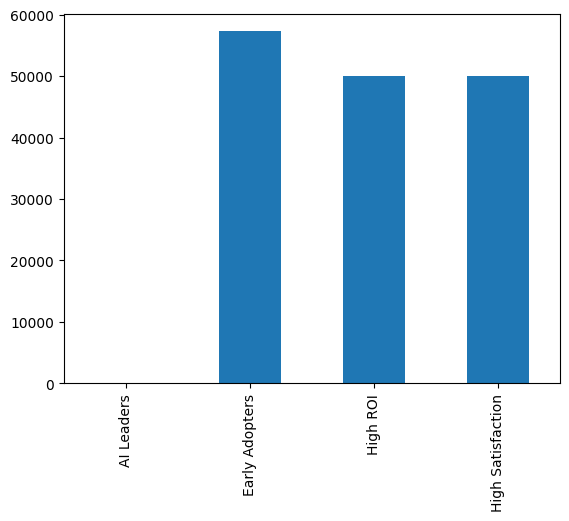

In [ ]:
segment_counts = {
    "AI Leaders": len(leaders),
    "Early Adopters": len(early),
    "High ROI": len(roi),
    "High Satisfaction": len(high_sat)
}

pd.Series(segment_counts).plot(
    kind="bar"
)

plt.show()